## 1. Setup & Imports

Import libraries and configure the project root path to access `src/` modules.

In [1]:
import sys
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import re
import csv

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


## 2. Load Raw Data

Load the raw `nigerian_fraud` CSV from the raw data directory and inspect its shape.

In [2]:
from src.config import RAW_DATA_DIR

csv.field_size_limit(50 * 1024 * 1024)
db = pd.read_csv(RAW_DATA_DIR / "nigerian_fraud.csv")
db.shape


(3332, 7)

In [3]:
db.head(2)


,sender,receiver,date,subject,body,urls,label
0,MR. JAMES NGOLA. <james_ngola2002@maktoob.com>,webmaster@aclweb.org,"Thu, 31 Oct 2002 02:38:20 +0000",URGENT BUSINESS ASSISTANCE AND PARTNERSHIP,FROM:MR. JAMES NGOLA.\nCONFIDENTIAL TEL: 233-2...,0,1
1,Mr. Ben Suleman <bensul2004nng@spinfinder.com>,R@M,"Thu, 31 Oct 2002 05:10:00 -0000",URGENT ASSISTANCE /RELATIONSHIP (P),"Dear Friend,\n\nI am Mr. Ben Suleman a custom ...",0,1


In [4]:
db.isnull().sum()


sender       331
receiver    1324
date         482
subject       39
body           0
urls           0
label          0
dtype: int64

In [5]:
db.info()


<class 'pandas.DataFrame'>
RangeIndex: 3332 entries, 0 to 3331
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sender    3001 non-null   str  
 1   receiver  2008 non-null   str  
 2   date      2850 non-null   str  
 3   subject   3293 non-null   str  
 4   body      3332 non-null   str  
 5   urls      3332 non-null   int64
 6   label     3332 non-null   int64
dtypes: int64(2), str(5)
memory usage: 182.3 KB


In [6]:
# check for empty string cells
for col in db.columns:
    empty = (db[col].astype(str).str.strip() == "").sum()
    if empty > 0:
        print(f"{col}: {empty} empty strings")


body: 1 empty strings


In [7]:
# combine subject + body into text, fill empty subject
db["subject"] = db["subject"].fillna("").astype(str).str.strip()
db["body"] = db["body"].fillna("").astype(str)
db["text"] = db["subject"] + " " + db["body"]
db["text"] = db["text"].str.strip()

print(f"Text samples after combine: {len(db)}")
print(f"Empty text count: {(db['text'] == '').sum()}")


Text samples after combine: 3332
Empty text count: 0


In [8]:
# urls column is binary, will recompute from text
db.drop(columns=["sender", "receiver", "date", "subject", "body", "urls"], inplace=True)
db.columns.tolist()


['label', 'text']

## 3. Feature Engineering

Extract numeric features from the raw text: URL count, exclamation/question marks, dollar signs, ALL-CAPS words, numbers, word count, and capitalisation ratio.

In [9]:
db["num_urls"]        = db["text"].str.findall(r'https?://\S+|www\.\S+').str.len()
db["num_exclamation"] = db["text"].str.count(r'!')
db["num_question"]    = db["text"].str.count(r'\?')
db["num_dollar"]      = db["text"].str.count(r'\$')
db["num_all_caps"]    = db["text"].str.findall(r'\b[A-Z]{2,}\b').str.len()
db["num_numbers"]     = db["text"].str.findall(r'\d+').str.len()
db["word_count"]      = db["text"].str.split().str.len()
caps   = db["text"].str.findall(r'[A-Z]').str.len()
letters = db["text"].str.findall(r'[A-Za-z]').str.len()
db["capital_ratio"]   = np.where(letters > 0, caps / letters, 0)


## 4. Emoji Count Feature

Count the number of emoji characters in each email text.

In [10]:
import emoji

db["emoji_count"] = db["text"].apply(emoji.emoji_count)


## 5. Exploratory Data Analysis

Visualise the class distribution with a pie chart and compare average feature values between spam and ham emails.

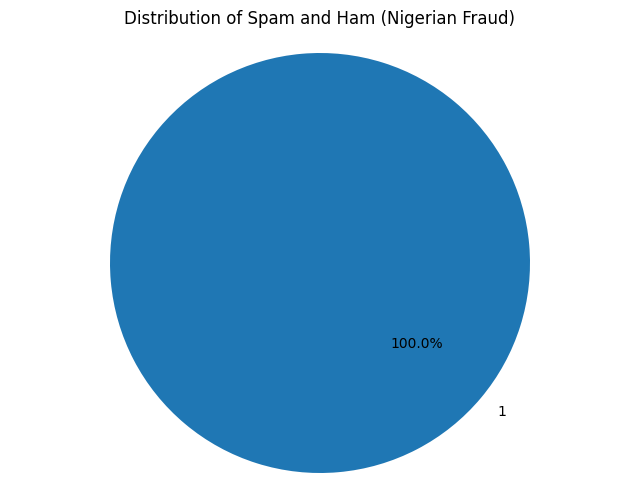

In [11]:
db['label'].value_counts()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.pie(db['label'].value_counts(), labels=db['label'].value_counts().index,
        autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Spam and Ham (Nigerian Fraud)')
plt.axis('equal')
plt.show()


In [12]:
db.groupby("label")["emoji_count"].mean()


label
1    0.003301
Name: emoji_count, dtype: float64

In [13]:
db.groupby('label')['num_exclamation'].mean()


label
1    0.609544
Name: num_exclamation, dtype: float64

In [14]:
db.groupby('label')['num_dollar'].mean()


label
1    1.163565
Name: num_dollar, dtype: float64

In [15]:
db.groupby('label')['num_question'].mean()


label
1    0.895258
Name: num_question, dtype: float64

In [16]:
db.groupby('label')['num_all_caps'].mean()


label
1    54.143758
Name: num_all_caps, dtype: float64

In [17]:
db.groupby('label')['capital_ratio'].mean()


label
1    0.159049
Name: capital_ratio, dtype: float64

In [18]:
db.groupby('label')['num_numbers'].mean()


label
1    10.705582
Name: num_numbers, dtype: float64

In [19]:
db.groupby('label')['num_urls'].mean()


label
1    0.577131
Name: num_urls, dtype: float64

In [20]:
db.groupby('label')['word_count'].mean()


label
1    446.797419
Name: word_count, dtype: float64

In [21]:
db.info()


<class 'pandas.DataFrame'>
RangeIndex: 3332 entries, 0 to 3331
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   label            3332 non-null   int64  
 1   text             3332 non-null   str    
 2   num_urls         3332 non-null   int64  
 3   num_exclamation  3332 non-null   int64  
 4   num_question     3332 non-null   int64  
 5   num_dollar       3332 non-null   int64  
 6   num_all_caps     3332 non-null   int64  
 7   num_numbers      3332 non-null   int64  
 8   word_count       3332 non-null   int64  
 9   capital_ratio    3332 non-null   float64
 10  emoji_count      3332 non-null   int64  
dtypes: float64(1), int64(9), str(1)
memory usage: 286.5 KB


## 6. Deduplication

Remove duplicate rows based on the `text` column to avoid data leakage.

In [22]:
db.drop_duplicates(subset="text", inplace=True)
db.shape


(3319, 11)

## 7. Text Cleaning

Import the `clean_db_text` function for heavy-duty text cleaning (bracket/hex removal, normalisation).

In [ ]:
from src.preprocess import clean_db_text


Apply `clean_db_text` to every row and re-deduplicate after cleaning.

In [24]:
db["text"] = db["text"].apply(clean_db_text)
db.drop_duplicates(subset="text", inplace=True)
print(f"After cleaning: {db.shape}")


After cleaning: (3249, 11)


In [25]:
db["text"].iloc[0]


'urgent business assistance and partnership frommr james ngola confidential tel [phonenumber] e-mail ( [email] ) urgent business assistance and partnership dear friend i am ( dr) james ngola the personal assistance to the late congolese (president laurent kabila) who was assassinated by his body guard on 16th jan [phonenumber] the incident occurred in our presence while we were holding meeting with his excellency over the financial returns from the diamond sales in the areas controlled by (drc) democratic republic of congo forces and their foreign allies angola and zimbabwe having received the previous day (usd$100m) one hundred million united states dollars cash in three diplomatic boxes routed through zimbabwe my purpose of writing you this letter is to solicit for your assistance as to be a cover to the fund and also collaboration in moving the said fund into your bank account the sum of (usd$25m) twenty five million united states dollars only which i deposited with a security compa

## 8. Regex Cleanup

Remove noise tokens: underscores, repeated `-+=` characters, and angle brackets/slashes.

In [26]:

# remove underscores
db["text"] = db["text"].str.replace("_", "", regex=False)

# remove repeated - + =
db["text"] = db["text"].str.replace(r'[-+=]{2,}', ' ', regex=True)

# remove > < / 
db["text"] = db["text"].str.replace(r'[<>/]', '', regex=True)


## 9. Advanced Text Processing

Apply stopword removal and stemming via `process_text_advanced`. (Cell may be left unexecuted.)

In [ ]:
from src.preprocess import process_text_advanced
db["text"] = db["text"].apply(process_text_advanced)


In [29]:
db["text"].iloc[0]


'urgent busi assist partnership frommr jame ngola confidenti tel [phonenumber] e-mail [email] urgent busi assist partnership dear friend dr jame ngola person assist late congoles presid laurent kabila assassin bodi guard 16th jan [phonenumber] incid occur presenc hold meet excel financi return diamond sale area control drc democrat republ congo forc foreign alli angola zimbabw receiv previou day usd$100m one hundr million unit state dollar cash three diplomat box rout zimbabw purpos write letter solicit assist cover fund also collabor move said fund bank account sum usd$25m twenti five million unit state dollar deposit secur compani ghana diplomat box gold worth usd$25m twenti five million unit state dollar safe keep secur vault invest perhap countri introduc reliabl friend mine travellerand also member chamber commerc reliabl trustworthi person reli foreign partner even though natur transact reveal secur reason usd$25m part proce diamond trade meant late presid laurent kabila deliv zi

In [30]:
db.shape


(3249, 11)

In [31]:
db["label"].value_counts()


label
1    3249
Name: count, dtype: int64

## 10. Save Cleaned Dataset

Write the cleaned and feature-engineered dataset to the processed data directory.

In [32]:
from src.config import PROCESSED_DATA_DIR
db.to_csv(PROCESSED_DATA_DIR / "cleaned_nigerian_fraud.csv", index=False)
print(f"Saved to {PROCESSED_DATA_DIR / 'cleaned_nigerian_fraud.csv'}")


Saved to C:\Users\aungm\university\computing\cos30049-email-spam-detection\data\processed\cleaned_nigerian_fraud.csv
